# Preprocessing of lung cosmx data to run mintflow

In [19]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import anndata as ad
import os
import gc
import re

In [2]:
path = "/nfs/team361/sb75/DATASETS/silver/chl59-8b_1p/"
save_dir = "/nfs/team361/ms83/data/lung/"

## Section 12

In [3]:
adata = sc.read_h5ad(path + 'Lung12+SMI+Flat+data.tar.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 72446 × 946
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'n_genes', 'cell_id', 'cell_type', 'niche'
    var: 'ensembl_id'
    uns: 'assay', 'batch', 'condition', 'dataset_id', 'species', 'tissue'
    obsm: 'spatial'

In [5]:
adata.obs

,fov,cell_ID,Area,AspectRatio,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,Width,Height,...,Mean.CD45,Max.CD45,Mean.CD3,Max.CD3,Mean.DAPI,Max.DAPI,n_genes,cell_id,cell_type,niche
1_1,1,1,3411,1.98,553,3625,-4424.777778,-156608.333333,93,47,...,78,588,80,610,12242,47623,78,59_batch0_0,neutrophil,8- Stroma
1_2,1,2,2993,1.77,819,3626,-4158.777778,-156607.333333,78,44,...,102,410,0,85,0,0,49,59_batch0_1,tumor,5- Infiltrated tumor
1_3,1,3,5590,1.75,1102,3616,-3875.777778,-156617.333333,112,64,...,79,495,0,133,611,23078,70,59_batch0_2,tumor,5- Infiltrated tumor
1_4,1,4,9932,1.19,1392,3596,-3585.777778,-156637.333333,124,104,...,63,369,0,190,1423,18333,204,59_batch0_3,tumor,5- Infiltrated tumor
1_5,1,5,3158,2.05,1567,3626,-3410.777778,-156607.333333,90,44,...,37,322,0,0,2576,23629,41,59_batch0_4,tumor,5- Infiltrated tumor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28_3144,28,3144,1917,1.18,450,38,11888.888889,-138295.333333,52,44,...,13,201,0,0,3206,17936,17,59_batch0_72441,NaN,NaN
28_3145,28,3145,1999,1.27,1910,38,13348.888889,-138295.333333,56,44,...,14,360,0,32,5732,38502,68,59_batch0_72442,fibroblast,8- Stroma
28_3146,28,3146,1883,1.33,1476,37,12914.888889,-138296.333333,56,42,...,25,302,0,0,4187,24065,120,59_batch0_72443,fibroblast,8- Stroma
28_3147,28,3147,1676,1.42,2639,35,14077.888889,-138298.333333,54,38,...,0,45,0,0,4516,30947,15,59_batch0_72444,NaN,NaN


In [6]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

In [7]:
adata.layers["counts"] = adata.X.copy()

In [8]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

Raw counts are stored in adata.layers['counts']


In [9]:
adata.obsm.keys()

KeysView(AxisArrays with keys: spatial)

In [21]:
patient = re.search(r"Lung(\d+)", 'Lung12+SMI+Flat+data.tar').group(1)
adata.obs["patient"] = patient
adata.obs["patient"] = adata.obs["patient"].astype(str) 

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


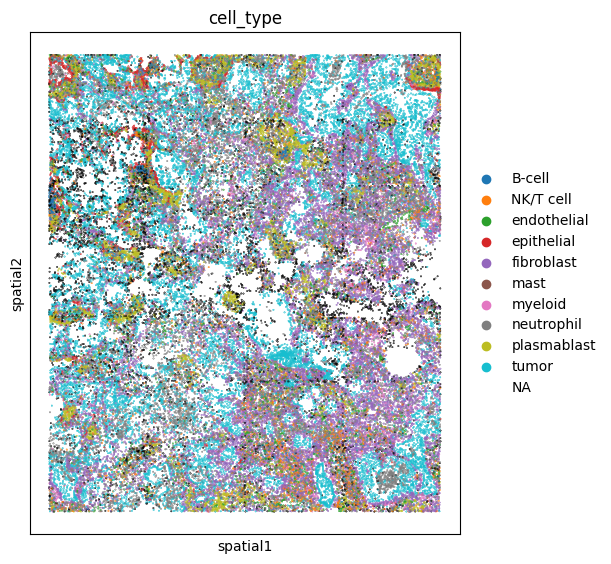

In [14]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "cell_type",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(6, 6)
)

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


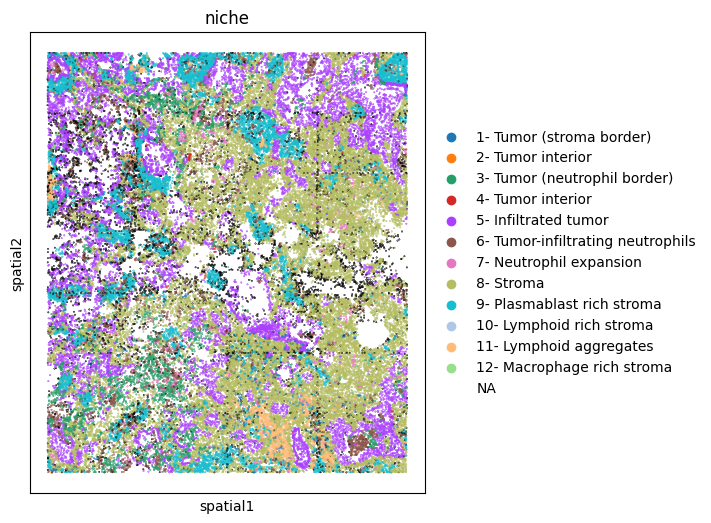

In [16]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "niche",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(7, 7)
)

In [22]:
adata.write_h5ad(save_dir + "Lung12+SMI+Flat+data_rawformintflow.h5ad")

In [25]:
adata.obs.cell_type.value_counts()

cell_type
tumor          17067
fibroblast     15955
neutrophil     15553
plasmablast     4857
NK/T cell       3658
endothelial     2842
myeloid         2437
epithelial      1937
B-cell          1193
mast             990
Name: count, dtype: int64

In [27]:
adata.obs['cell_type'].isna()

1_1        False
1_2        False
1_3        False
1_4        False
1_5        False
           ...  
28_3144     True
28_3145    False
28_3146    False
28_3147     True
28_3148    False
Name: cell_type, Length: 72446, dtype: bool

In [29]:
adata = adata[~adata.obs['cell_type'].isna()].copy()
adata.obs['cell_type'] = adata.obs['cell_type'].astype(str).astype("category")

In [32]:
adata.obs['cell_type'].isna()

1_1        False
1_2        False
1_3        False
1_4        False
1_5        False
           ...  
28_3142    False
28_3143    False
28_3145    False
28_3146    False
28_3148    False
Name: cell_type, Length: 66489, dtype: bool

In [33]:
adata = adata[~adata.obs['niche'].isna()].copy()
adata.obs['niche'] = adata.obs['niche'].astype(str).astype("category")

In [34]:
adata.write_h5ad(save_dir + "Lung12+SMI+Flat+data_rawformintflow.h5ad")

## Section 9

In [68]:
adata = sc.read_h5ad(path + 'Lung9_Rep1+SMI+Flat+data.tar.h5ad')

In [69]:
adata

AnnData object with n_obs × n_vars = 89752 × 946
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'n_genes', 'cell_id', 'cell_type', 'niche'
    var: 'ensembl_id'
    uns: 'assay', 'batch', 'condition', 'dataset_id', 'species', 'tissue'
    obsm: 'spatial'

In [70]:
adata.obs

,fov,cell_ID,Area,AspectRatio,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,Width,Height,...,Mean.CD45,Max.CD45,Mean.CD3,Max.CD3,Mean.DAPI,Max.DAPI,n_genes,cell_id,cell_type,niche
1_2,1,2,4191,2.20,180,3623,1913.333333,140378.555556,112,51,...,100,7803,79,335,332,942,48,59_batch1_0,tumor,6- Tumor-infiltrating neutrophils
1_3,1,3,4566,0.97,424,3609,2157.333333,140364.555556,76,78,...,116,1023,175,751,443,1814,41,59_batch1_1,NaN,NaN
1_4,1,4,4288,1.48,617,3617,2350.333333,140372.555556,92,62,...,125,1144,297,1292,643,1467,26,59_batch1_2,NaN,NaN
1_6,1,6,1708,1.33,793,3627,2526.333333,140382.555556,56,42,...,112,917,155,690,563,2044,23,59_batch1_3,NaN,NaN
1_7,1,7,2562,0.95,838,3618,2571.333333,140373.555556,57,60,...,125,821,356,949,361,1442,59,59_batch1_4,neutrophil,7- Neutrophil expansion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20_4048,20,4048,1665,1.61,3630,20,21780.000000,151375.555556,61,38,...,191,454,92,444,339,925,108,59_batch1_89747,tumor,1- Tumor (stroma border)
20_4049,20,4049,1957,1.79,4401,21,22551.000000,151376.555556,70,39,...,170,491,66,377,409,1033,86,59_batch1_89748,tumor,1- Tumor (stroma border)
20_4050,20,4050,1312,1.29,4653,19,22803.000000,151374.555556,45,35,...,158,438,70,344,448,855,86,59_batch1_89749,tumor,1- Tumor (stroma border)
20_4051,20,4051,891,1.45,4007,16,22157.000000,151371.555556,42,29,...,157,498,62,281,183,702,56,59_batch1_89750,tumor,1- Tumor (stroma border)


In [71]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

In [72]:
adata.layers["counts"] = adata.X.copy()

In [73]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

Raw counts are stored in adata.layers['counts']


In [74]:
adata.obsm.keys()

KeysView(AxisArrays with keys: spatial)

In [75]:
patient = re.search(r"Lung(\d+)", 'Lung9_Rep1+SMI+Flat+data.tar').group(1)
print(patient)
adata.obs["patient"] = patient
adata.obs["patient"] = adata.obs["patient"].astype(str) 

9


/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


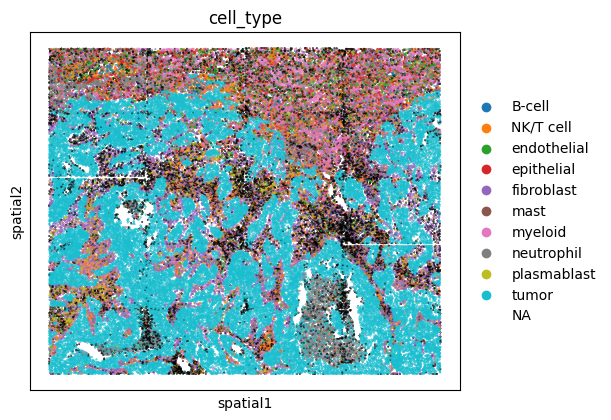

In [76]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "cell_type",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(6, 6)
)

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


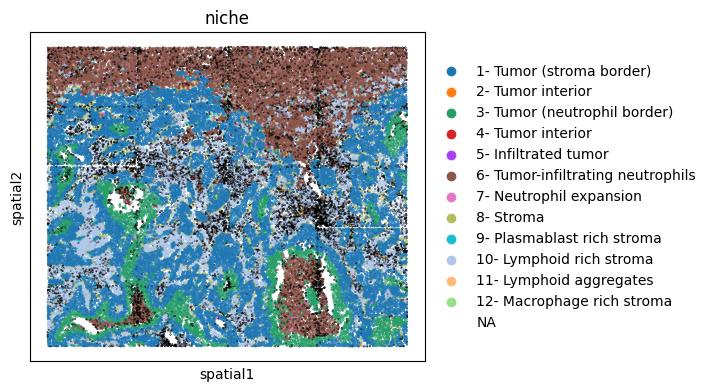

In [77]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "niche",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(7, 7)
)

In [78]:
adata.obs.cell_type.value_counts()

cell_type
tumor          37984
fibroblast     11309
myeloid         6828
NK/T cell       6403
neutrophil      4868
endothelial     3585
epithelial      3078
plasmablast     2445
B-cell           676
mast             212
Name: count, dtype: int64

In [79]:
adata.obs['cell_type'].isna()

1_2        False
1_3         True
1_4         True
1_6         True
1_7        False
           ...  
20_4048    False
20_4049    False
20_4050    False
20_4051    False
20_4052    False
Name: cell_type, Length: 89752, dtype: bool

In [80]:
adata = adata[~adata.obs['cell_type'].isna()].copy()
adata.obs['cell_type'] = adata.obs['cell_type'].astype(str).astype("category")

In [81]:
adata.obs['cell_type'].isna()

1_2        False
1_7        False
1_8        False
1_9        False
1_10       False
           ...  
20_4048    False
20_4049    False
20_4050    False
20_4051    False
20_4052    False
Name: cell_type, Length: 77388, dtype: bool

In [82]:
adata = adata[~adata.obs['niche'].isna()].copy()
adata.obs['niche'] = adata.obs['niche'].astype(str).astype("category")

In [83]:
adata.write_h5ad(save_dir + "Lung9_Rep1+SMI+Flat+data_rawformintflow.h5ad")

## Section 6

In [52]:
adata = sc.read_h5ad(path + 'Lung6+SMI+Flat+data.tar.h5ad')

In [53]:
adata

AnnData object with n_obs × n_vars = 91735 × 946
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'n_genes', 'cell_id', 'cell_type', 'niche'
    var: 'ensembl_id'
    uns: 'assay', 'batch', 'condition', 'dataset_id', 'species', 'tissue'
    obsm: 'spatial'

In [54]:
adata.obs

,fov,cell_ID,Area,AspectRatio,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,Width,Height,...,Mean.CD45,Max.CD45,Mean.CD3,Max.CD3,Mean.DAPI,Max.DAPI,n_genes,cell_id,cell_type,niche
1_1,1,1,4099,0.92,305,3609,-5450.555556,-181318.777778,73,79,...,170,738,0,0,5842,24372,17,59_batch4_0,NaN,NaN
1_2,1,2,5109,1.52,426,3615,-5329.555556,-181312.777778,100,66,...,58,343,0,0,496,8936,11,59_batch4_1,NaN,NaN
1_3,1,3,2930,1.00,787,3615,-4968.555556,-181312.777778,67,67,...,645,2808,0,30,4814,31312,15,59_batch4_2,NaN,NaN
1_4,1,4,2354,1.31,852,3624,-4903.555556,-181303.777778,64,49,...,301,1057,0,0,4912,21525,25,59_batch4_3,NaN,NaN
1_5,1,5,2657,1.18,2447,3623,-3308.555556,-181304.777778,59,50,...,168,623,0,8,3950,13319,49,59_batch4_4,tumor,2- Tumor interior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30_2750,30,2750,1857,3.78,2467,15,18600.333333,-166662.777778,102,27,...,189,459,0,86,6357,18158,15,59_batch4_91730,NaN,NaN
30_2752,30,2752,1501,2.96,2101,14,18234.333333,-166663.777778,74,25,...,155,388,0,185,7620,25916,28,59_batch4_91731,NaN,NaN
30_2753,30,2753,1757,3.40,3348,14,19481.333333,-166663.777778,85,25,...,128,455,0,0,2431,7588,29,59_batch4_91732,NaN,NaN
30_2754,30,2754,1262,2.83,2367,13,18500.333333,-166664.777778,65,23,...,169,421,0,0,5824,26886,20,59_batch4_91733,NaN,NaN


In [55]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

In [56]:
adata.layers["counts"] = adata.X.copy()

In [57]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

Raw counts are stored in adata.layers['counts']


In [58]:
adata.obsm.keys()

KeysView(AxisArrays with keys: spatial)

In [59]:
patient = re.search(r"Lung(\d+)", 'Lung6+SMI+Flat+data.tar').group(1)
print(patient)
adata.obs["patient"] = patient
adata.obs["patient"] = adata.obs["patient"].astype(str) 

6


/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


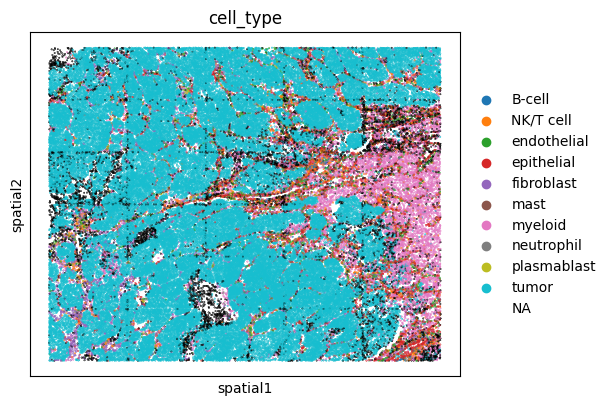

In [60]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "cell_type",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(6, 6)
)

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


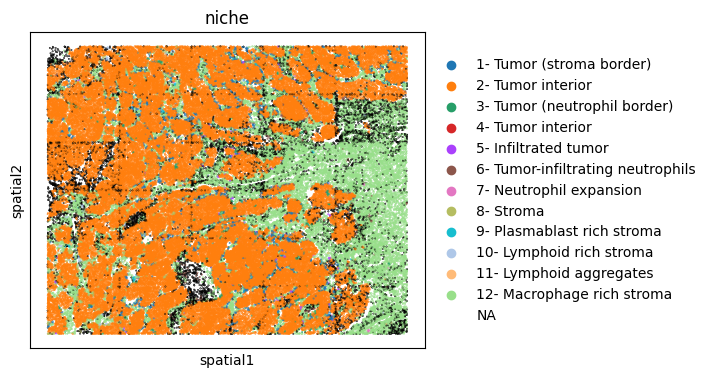

In [61]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "niche",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(7, 7)
)

In [62]:
adata.obs.cell_type.value_counts()

cell_type
tumor          64026
myeloid         7705
epithelial      3692
fibroblast      2747
endothelial     2211
NK/T cell       2200
B-cell           372
plasmablast      342
neutrophil       219
mast             209
Name: count, dtype: int64

In [63]:
adata.obs['cell_type'].isna()

1_1         True
1_2         True
1_3         True
1_4         True
1_5        False
           ...  
30_2750     True
30_2752     True
30_2753     True
30_2754     True
30_2756     True
Name: cell_type, Length: 91735, dtype: bool

In [64]:
adata = adata[~adata.obs['cell_type'].isna()].copy()
adata.obs['cell_type'] = adata.obs['cell_type'].astype(str).astype("category")

In [65]:
adata.obs['cell_type'].isna()

1_5        False
1_8        False
1_10       False
1_11       False
1_12       False
           ...  
30_2739    False
30_2741    False
30_2743    False
30_2745    False
30_2746    False
Name: cell_type, Length: 83723, dtype: bool

In [66]:
adata = adata[~adata.obs['niche'].isna()].copy()
adata.obs['niche'] = adata.obs['niche'].astype(str).astype("category")

In [67]:
adata.write_h5ad(save_dir + "Lung6+SMI+Flat+data_rawformintflow.h5ad")

## Section 5

In [84]:
adata = sc.read_h5ad(path + 'Lung5_Rep1+SMI+Flat+data.tar.h5ad')

In [85]:
adata

AnnData object with n_obs × n_vars = 98846 × 946
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'n_genes', 'cell_id', 'cell_type', 'niche'
    var: 'ensembl_id'
    uns: 'assay', 'batch', 'condition', 'dataset_id', 'species', 'tissue'
    obsm: 'spatial'

In [86]:
adata.obs

,fov,cell_ID,Area,AspectRatio,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,Width,Height,...,Mean.CD45,Max.CD45,Mean.CD3,Max.CD3,Mean.DAPI,Max.DAPI,n_genes,cell_id,cell_type,niche
1_1,1,1,1259,1.34,1027,3631,4215.888889,158847.666667,47,35,...,361,845,22,731,4979,26374,19,59_batch6_0,NaN,NaN
1_2,1,2,3723,1.45,2904,3618,6092.888889,158834.666667,87,60,...,260,1232,13,686,1110,13229,22,59_batch6_1,NaN,NaN
1_3,1,3,2010,1.62,4026,3627,7214.888889,158843.666667,68,42,...,378,908,19,654,10482,33824,48,59_batch6_2,endothelial,6- Tumor-infiltrating neutrophils
1_4,1,4,3358,0.47,4230,3597,7418.888889,158813.666667,48,102,...,679,2322,5,582,6065,39512,45,59_batch6_3,myeloid,6- Tumor-infiltrating neutrophils
1_5,1,5,1213,1.00,4258,3629,7446.888889,158845.666667,38,38,...,566,1242,17,674,3311,30136,36,59_batch6_4,myeloid,6- Tumor-infiltrating neutrophils
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30_4750,30,4750,1614,2.06,1864,17,26941.777778,173483.666667,64,31,...,238,693,0,0,4078,16524,30,59_batch6_98841,NaN,NaN
30_4751,30,4751,1346,2.83,1936,13,27013.777778,173479.666667,68,24,...,274,634,1,191,9668,27367,52,59_batch6_98842,fibroblast,8- Stroma
30_4752,30,4752,1336,1.86,4707,16,29784.777778,173482.666667,54,29,...,246,516,0,20,2508,9627,49,59_batch6_98843,myeloid,8- Stroma
30_4753,30,4753,803,2.58,5024,11,30101.777778,173477.666667,49,19,...,512,944,0,0,19105,25580,13,59_batch6_98844,NaN,NaN


In [87]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

In [88]:
adata.layers["counts"] = adata.X.copy()

In [89]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

Raw counts are stored in adata.layers['counts']


In [90]:
adata.obsm.keys()

KeysView(AxisArrays with keys: spatial)

In [91]:
patient = re.search(r"Lung(\d+)", 'Lung5_Rep1+SMI+Flat+data.tar').group(1)
print(patient)
adata.obs["patient"] = patient
adata.obs["patient"] = adata.obs["patient"].astype(str) 

5


/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


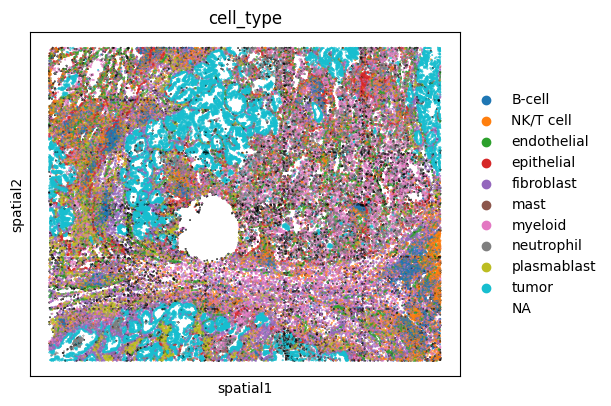

In [92]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "cell_type",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(6, 6)
)

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


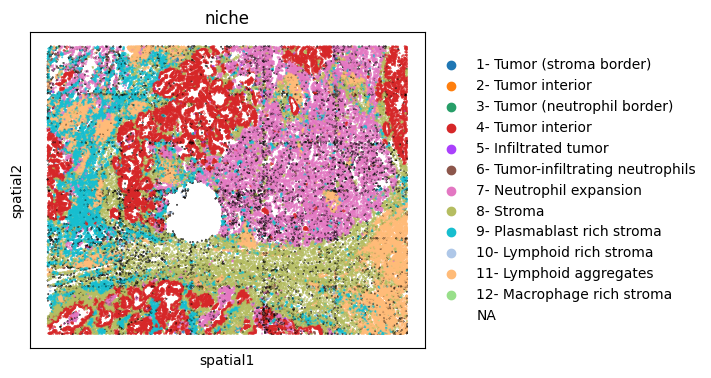

In [93]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "niche",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(7, 7)
)

In [94]:
adata.obs.cell_type.value_counts()

cell_type
tumor          18217
myeloid        15564
fibroblast     12673
NK/T cell      10886
neutrophil      8530
endothelial     7330
B-cell          6978
plasmablast     6805
epithelial      3903
mast            2320
Name: count, dtype: int64

In [95]:
adata.obs['cell_type'].isna()

1_1         True
1_2         True
1_3        False
1_4        False
1_5        False
           ...  
30_4750     True
30_4751    False
30_4752    False
30_4753     True
30_4755     True
Name: cell_type, Length: 98846, dtype: bool

In [96]:
adata = adata[~adata.obs['cell_type'].isna()].copy()
adata.obs['cell_type'] = adata.obs['cell_type'].astype(str).astype("category")

In [97]:
adata.obs['cell_type'].isna()

1_3        False
1_4        False
1_5        False
1_7        False
1_9        False
           ...  
30_4745    False
30_4746    False
30_4747    False
30_4751    False
30_4752    False
Name: cell_type, Length: 93206, dtype: bool

In [98]:
adata = adata[~adata.obs['niche'].isna()].copy()
adata.obs['niche'] = adata.obs['niche'].astype(str).astype("category")

In [99]:
adata.write_h5ad(save_dir + "Lung5_Rep1+SMI+Flat+data_rawformintflow.h5ad")